# pandas Basics

In this notebook, we will learn the most useful pandas ideas for data science and machine learning.

You will practice:
- creating DataFrames
- reading CSV files
- selecting and filtering rows
- working with columns
- grouping and summarizing data
- saving results back to CSV

These skills will help you manage labels, predictions, and metadata in later labs.

## What is pandas?

pandas is a Python library for working with tabular data.

A table in pandas is called a **DataFrame**.

A single column in a DataFrame is called a **Series**.

In [1]:
import pandas as pd
import numpy as np

## Create a simple DataFrame

We start with a small example table so we can see the basic structure clearly.

In [2]:
data = {
    "name": ["cat_1", "dog_1", "cat_2", "dog_2"],
    "label": ["cat", "dog", "cat", "dog"],
    "score": [0.91, 0.12, 0.85, 0.33]
}

df = pd.DataFrame(data)
print(df)

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12
2  cat_2   cat   0.85
3  dog_2   dog   0.33


In [3]:
# Check the shape of the table.
# This tells us how many rows and columns there are.

print("Shape:", df.shape)

Shape: (4, 3)


In [4]:
# Show the column names.

print("Columns:", df.columns.tolist())

Columns: ['name', 'label', 'score']


In [5]:
# Look at the data types of each column.

print(df.dtypes)

name         str
label        str
score    float64
dtype: object


## Select columns

In pandas, we can access one column or multiple columns easily.

In [6]:
# Select one column.
# The result is a pandas Series.

print(df["label"])

0    cat
1    dog
2    cat
3    dog
Name: label, dtype: str


In [7]:
# Select multiple columns.
# The result is a DataFrame.

print(df[["name", "score"]])

    name  score
0  cat_1   0.91
1  dog_1   0.12
2  cat_2   0.85
3  dog_2   0.33


## Select rows

We often want only some rows, not the entire table.

In [8]:
# Select the first two rows.

print(df.head(2))

    name label  score
0  cat_1   cat   0.91
1  dog_1   dog   0.12


In [9]:
# Select a row by integer position.

print(df.iloc[1])

name     dog_1
label      dog
score     0.12
Name: 1, dtype: object


## Filtering rows

Filtering means keeping only rows that satisfy a condition.
This is one of the most important pandas skills for machine learning.

In [10]:
# Keep only rows where the label is cat.

cat_rows = df[df["label"] == "cat"]
print(cat_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


In [11]:
# Keep only rows where the score is greater than 0.5.

high_score_rows = df[df["score"] > 0.5]
print(high_score_rows)

    name label  score
0  cat_1   cat   0.91
2  cat_2   cat   0.85


## Add or modify columns

pandas makes it easy to create new columns from existing ones.

In [12]:
# Create a new boolean column that says whether the score is high.

df["high_score"] = df["score"] > 0.5
print(df)

    name label  score  high_score
0  cat_1   cat   0.91        True
1  dog_1   dog   0.12       False
2  cat_2   cat   0.85        True
3  dog_2   dog   0.33       False


In [13]:
# Create a new column using a simple rule.

df["score_scaled"] = df["score"] * 100
print(df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


## Sorting

Sorting is useful when we want to rank examples by a score.

In [14]:
# Sort by score from largest to smallest.

sorted_df = df.sort_values("score", ascending=False)
print(sorted_df)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0
1  dog_1   dog   0.12       False          12.0


## Grouping and summarizing

Grouping helps us compute summaries for each class.
This is useful when checking balance between cat and dog examples.

In [15]:
# Compute the average score for each label.

group_mean = df.groupby("label")["score"].mean()
print(group_mean)

label
cat    0.880
dog    0.225
Name: score, dtype: float64


In [16]:
# Count how many rows belong to each label.

group_count = df.groupby("label").size()
print(group_count)

label
cat    2
dog    2
dtype: int64


## Read and write CSV files

This is a very important skill for machine learning projects.
We often store predictions, labels, and metadata in CSV files.

In [17]:
# Save the small table to CSV.

df.to_csv("example.csv", index=False)
print("Saved example.csv")

Saved example.csv


In [18]:
# Read it back from disk.

df_loaded = pd.read_csv("example.csv")
print(df_loaded)

    name label  score  high_score  score_scaled
0  cat_1   cat   0.91        True          91.0
1  dog_1   dog   0.12       False          12.0
2  cat_2   cat   0.85        True          85.0
3  dog_2   dog   0.33       False          33.0


# Standard EDA Flow for Tabular Data

EDA means **Exploratory Data Analysis**.

Before building any model, we should understand the table carefully:
- how big it is
- what each column means
- whether there are missing values
- whether categories are balanced
- whether there are outliers
- whether the numerical columns look reasonable

Good EDA helps us avoid mistakes later.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots easier to read in notebooks.
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Step 1: Load the data

In a real project, the first step is usually to read a CSV file or load a table from a database.

For this tutorial, we will use a small example DataFrame so we can focus on the EDA workflow.

In [20]:
# Example tabular dataset with both numeric and categorical columns.
# We also include a missing value and a duplicate row to make the EDA more realistic.

df = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5, 6, 6],
    "age": [18, 19, 18, 20, 19, np.nan, np.nan],
    "study_hours": [2.5, 3.0, 1.0, 4.5, 2.0, 5.0, 5.0],
    "score": [72, 80, 55, 91, 68, 95, 95],
    "major": ["CS", "Math", "CS", "Physics", "Math", "CS", "CS"]
})

df

,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,55,CS
3,4,20.0,4.5,91,Physics
4,5,19.0,2.0,68,Math
5,6,NaN,5.0,95,CS
6,6,NaN,5.0,95,CS


## Step 2: Check the shape and preview the first rows

This tells us:
- how many rows and columns there are
- what the data looks like at a glance
- whether the column names make sense

In [21]:
print("Shape:", df.shape)
print("\nFirst few rows:")
display(df.head())

Shape: (7, 5)

First few rows:


,student_id,age,study_hours,score,major
0,1,18.0,2.5,72,CS
1,2,19.0,3.0,80,Math
2,3,18.0,1.0,55,CS
3,4,20.0,4.5,91,Physics
4,5,19.0,2.0,68,Math


## Step 3: Check column types and non-missing counts

This helps us see:
- which columns are numeric
- which columns are categorical
- where missing values may exist

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   7 non-null      int64  
 1   age          5 non-null      float64
 2   study_hours  7 non-null      float64
 3   score        7 non-null      int64  
 4   major        7 non-null      str    
dtypes: float64(2), int64(2), str(1)
memory usage: 412.0 bytes


## Step 4: Check missing values and duplicates

This is a very important part of EDA.

Missing values can affect analysis, and duplicate rows may mean repeated records or data quality issues.

In [23]:
print("Missing values per column:")
print(df.isna().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
student_id     0
age            2
study_hours    0
score          0
major          0
dtype: int64

Number of duplicate rows:
1


## Step 5: Summary statistics

Use summary statistics to understand the distribution of numeric columns.

For categorical columns, use value counts to check the class balance.

In [24]:
print("Numeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df["major"].value_counts())

Numeric summary:


,student_id,age,study_hours,score
count,7.000000,5.00000,7.000000,7.000000
mean,3.857143,18.80000,3.285714,79.428571
std,1.951800,0.83666,1.577370,15.284602
min,1.000000,18.00000,1.000000,55.000000
25%,2.500000,18.00000,2.250000,70.000000
50%,4.000000,19.00000,3.000000,80.000000
75%,5.500000,19.00000,4.750000,93.000000
max,6.000000,20.00000,5.000000,95.000000



Categorical summary:


major
CS         4
Math       2
Physics    1
Name: count, dtype: int64

## Step 6: Look at one variable at a time

A good EDA workflow includes simple plots:
- histograms for numeric columns
- bar charts for categorical columns

These plots can reveal skew, imbalance, and unusual values.

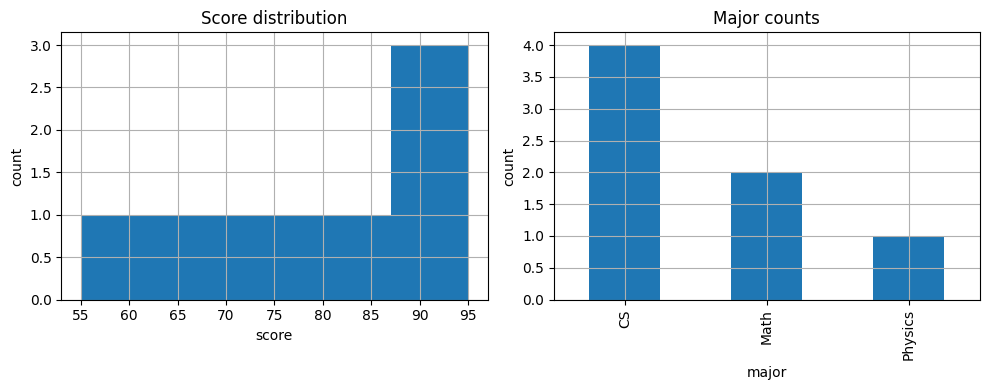

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram for a numeric column
axes[0].hist(df["score"].dropna(), bins=5)
axes[0].set_title("Score distribution")
axes[0].set_xlabel("score")
axes[0].set_ylabel("count")

# Bar chart for a categorical column
df["major"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Major counts")
axes[1].set_xlabel("major")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

## Step 7: Compare variables to each other

Now we look at relationships between columns.

For tabular data, common questions are:
- Does study time relate to score?
- Are some categories associated with higher values?
- Are there outliers?

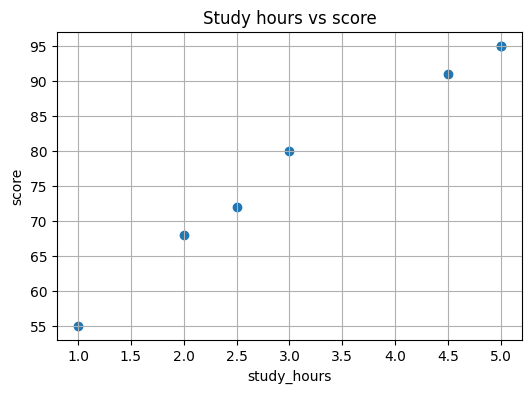

In [26]:
# Scatter plot for two numeric columns.
plt.figure(figsize=(6, 4))
plt.scatter(df["study_hours"], df["score"])
plt.title("Study hours vs score")
plt.xlabel("study_hours")
plt.ylabel("score")
plt.show()

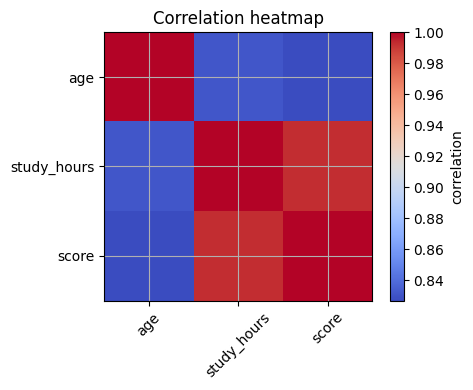

,age,study_hours,score
age,1.000000,0.831163,0.826904
study_hours,0.831163,1.000000,0.992991
score,0.826904,0.992991,1.000000


In [27]:
# Correlation matrix for numeric columns.
# Correlation is useful, but it does not replace plotting.

numeric_df = df[["age", "study_hours", "score"]]
corr = numeric_df.corr()

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

display(corr)

## Step 8: Detect outliers with box plots

A **box plot** is one of the best tools to detect outliers.

It shows:
- median (middle value)
- quartiles (spread of the data)
- potential outliers (points far away from the rest)

Outliers are usually values that are much larger or smaller than the majority of the data.

These could be:
- data entry mistakes
- rare but valid cases
- important edge cases for your model

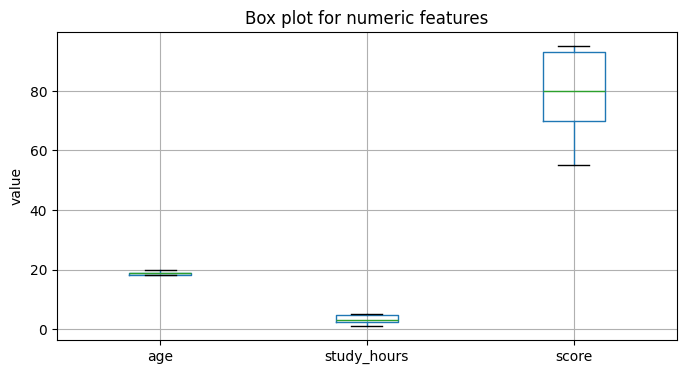

In [28]:
# Create a box plot for numeric columns.

numeric_cols = ["age", "study_hours", "score"]

plt.figure(figsize=(8, 4))
df[numeric_cols].boxplot()

plt.title("Box plot for numeric features")
plt.ylabel("value")
plt.show()

## How to read the box plot

- The **box** shows the middle 50% of the data (interquartile range)
- The **line inside the box** is the median
- The **whiskers** extend to typical values
- Points outside the whiskers are **potential outliers**

If you see points far away from the box, investigate them.

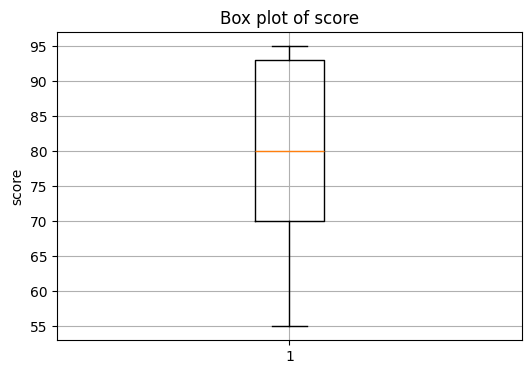

In [29]:
# Look at one column more closely.

plt.figure(figsize=(6, 4))
plt.boxplot(df["score"].dropna())

plt.title("Box plot of score")
plt.ylabel("score")
plt.show()

In [30]:
# Identify outliers using the IQR rule

Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Any value below the lower bound or above the upper bound is a outlier
outliers = df[(df["score"] < lower_bound) | (df["score"] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("\nPotential outliers:")
display(outliers)

Lower bound: 35.5
Upper bound: 127.5

Potential outliers:


,student_id,age,study_hours,score,major


## Fun example: Why plotting matters - a Datasaurus Dozen-style example

The Datasaurus Dozen is a famous reminder that different datasets can have very similar summary statistics, even though their shapes are completely different.

That means:
- mean may look the same
- standard deviation may look similar
- correlation may look similar

But the plot can tell a very different story.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file.
# Adjust the path if needed.
df = pd.read_csv("/workspaces/cats-and-dogs-faces-ex/labs/datasaurus.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (1846, 3)


,dataset,x,y
0,dino,55.3846,97.1795
1,dino,51.5385,96.0256
2,dino,46.1538,94.4872
3,dino,42.8205,91.4103
4,dino,40.7692,88.3333


In [34]:
# Check the column names and data types.

print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Columns: ['dataset', 'x', 'y']

Data types:
dataset        str
x          float64
y          float64
dtype: object

Missing values:
dataset    0
x          0
y          0
dtype: int64


In [35]:
# Overall summary statistics for x and y.

display(df[["x", "y"]].describe())

,x,y
count,1846.000000,1846.000000
mean,54.265695,47.835099
std,16.713001,26.847766
min,15.560750,0.015119
25%,41.073403,22.561073
50%,52.591269,47.594450
75%,67.277845,71.810778
max,98.288123,99.694680


In [36]:
# Summary statistics for each dataset group.

group_stats = df.groupby("dataset")[["x", "y"]].agg(["mean", "std", "min", "max", "median"])
display(group_stats)

x                                                      y  \
                 mean        std        min        max     median       mean   
dataset                                                                        
away        54.266100  16.769825  15.560750  91.639961  53.340296  47.834721   
bullseye    54.268730  16.769239  19.288205  91.735539  53.842088  47.830823   
circle      54.267320  16.760013  21.863581  85.664761  54.023213  47.837717   
dino        54.263273  16.765142  22.307700  98.205100  53.333300  47.832253   
dots        54.260303  16.767735  25.443526  77.954435  50.976768  47.839829   
h_lines     54.261442  16.765898  22.003709  98.288123  53.069678  47.830252   
high_lines  54.268805  16.766704  17.893499  96.080519  54.168689  47.835450   
slant_down  54.267849  16.766759  18.109472  95.593416  53.135159  47.835896   
slant_up    54.265882  16.768853  20.209778  95.260528  54.261345  47.831496   
star        54.267341  16.768959  27.024603  86.435897  56.534732  47.839545   
v_lines     54.269927  16.769959  30.449654  89.504851  50.362890  47.836988   
wide_lines  54.266916  16.770000  27.439632  77.915874  64.550226  47.831602   
x_shape     54.260150  16.769958  31.106867  85.446186  47.136458  47.839717   

                                                        
                  std        min        max     median  
dataset                                                 
away        26.939743   0.015119  97.475771  47.535269  
bullseye    26.935727   9.691547  85.876229  47.382937  
circle      26.930036  16.326546  85.578134  51.025022  
dino        26.935403   2.948700  99.487200  46.025600  
dots        26.930192  15.771892  94.249328  51.299291  
h_lines     26.939876  10.463915  90.458936  50.473527  
high_lines  26.939998  14.913962  87.152208  32.499203  
slant_down  26.936105   0.303872  99.644179  46.401314  
slant_up    26.938608   5.645777  99.579591  45.292238  
star        26.930275  14.365590  92.214989  50.110554  
v_lines     26.937684   2.734760  99.694680  47.113616  
wide_lines  26.937902   0.217006  99.283764  46.279331  
x_shape     26.930002   4.577661  97.837615  39.876211

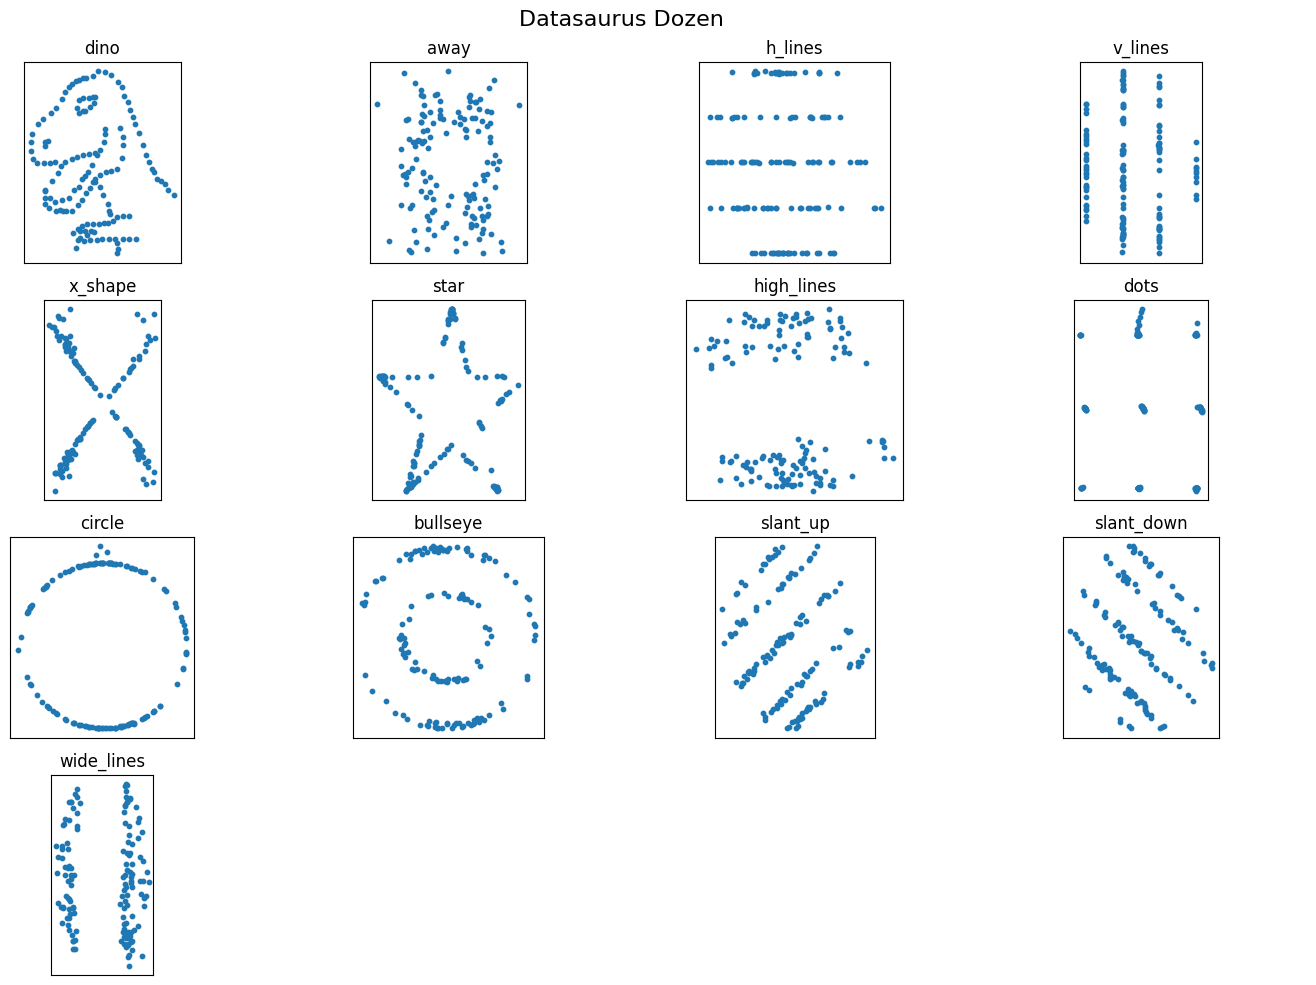

In [37]:
# Plot all datasets in a grid.

datasets = df["dataset"].unique()
n_plots = len(datasets)
ncols = 4
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
axes = np.array(axes).reshape(-1)

for ax, name in zip(axes, datasets):
    subset = df[df["dataset"] == name]
    ax.scatter(subset["x"], subset["y"], s=10)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")

# Hide unused subplots
for ax in axes[n_plots:]:
    ax.axis("off")

plt.suptitle("Datasaurus Dozen", fontsize=16)
plt.tight_layout()
plt.show()

### Reflection

The summary statistics may look similar across datasets, but the plots can be very different.

This is why EDA should always include both:
- numerical summaries
- visual inspection